In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/cleaned/retail_inventory_cleaned.csv')

In [4]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Month,Month_Name,Quarter,Forecast_Error,Absolute_Forecast_Error,Inventory_Value,Discount_Flag,Stock_Coverage,Inventory_Risk,Price_Difference
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,...,1,January,1,-8.47,8.47,7738.50,Discounted,1.705175,Low Risk,3.81
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,...,1,January,1,5.96,5.96,12854.04,Discounted,1.416273,Low Risk,-3.15
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,...,1,January,1,-9.02,9.02,2854.98,Discounted,1.378006,Low Risk,-3.33
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,...,1,January,1,-1.18,1.18,15345.68,Discounted,7.542618,Low Risk,-2.02
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,...,1,January,1,4.74,4.74,12224.24,Non-Discounted,17.926566,Low Risk,4.69


In [5]:
import os

print(os.listdir('../data'))

['Cleaned', 'Raw Data']


In [6]:
print(os.listdir('../data/cleaned'))

['retail_inventory_cleaned.csv']


In [7]:
df['Inventory_Value'].sum()

np.float64(1108476100.3000002)

In [8]:
# Total Units Sold
df['Units Sold'].sum()

np.int64(9975582)

In [9]:
# Total Inventory Value
df['Inventory_Value'].sum()

np.float64(1108476100.3000002)

In [10]:
# Average Demand Forecast
df['Demand Forecast'].mean()

np.float64(141.4947201094391)

In [11]:
# Average Forecast Error
df['Absolute_Forecast_Error'].mean()

np.float64(8.338075512995896)

In [12]:
category_sales = (
    df.groupby('Category')['Units Sold']
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Furniture      2025017
Groceries      2000482
Clothing       1999166
Toys           1990485
Electronics    1960432
Name: Units Sold, dtype: int64

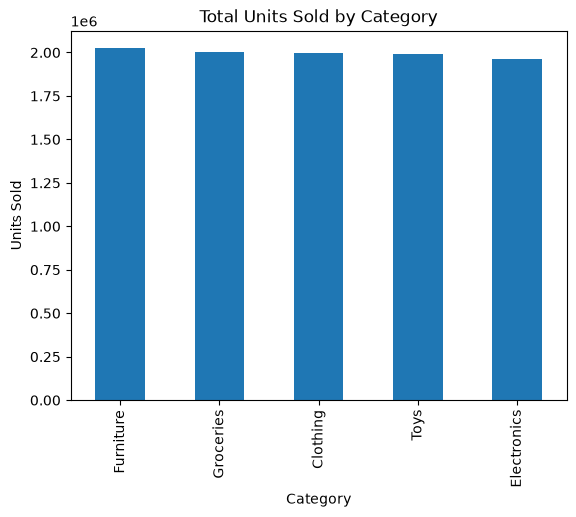

In [13]:
category_sales.plot(kind='bar')

plt.title('Total Units Sold by Category')
plt.ylabel('Units Sold')
plt.show()

In [14]:
df.groupby('Category')['Inventory_Value'] \
  .sum() \
  .sort_values(ascending=False)

Category
Furniture      2.240454e+08
Groceries      2.233965e+08
Clothing       2.214492e+08
Toys           2.206332e+08
Electronics    2.189518e+08
Name: Inventory_Value, dtype: float64

In [15]:
region_sales = (
    df.groupby('Region')['Units Sold']
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
East     2511265
South    2507799
North    2484966
West     2471552
Name: Units Sold, dtype: int64

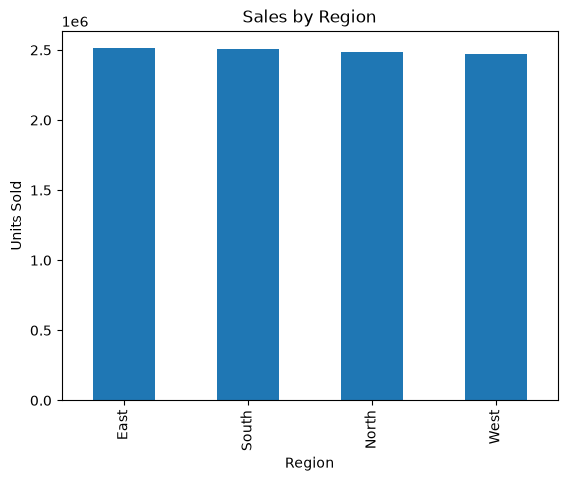

In [16]:
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.ylabel('Units Sold')
plt.show()

In [17]:
df['Inventory_Risk'].value_counts()

Inventory_Risk
Low Risk     70515
High Risk     2585
Name: count, dtype: int64

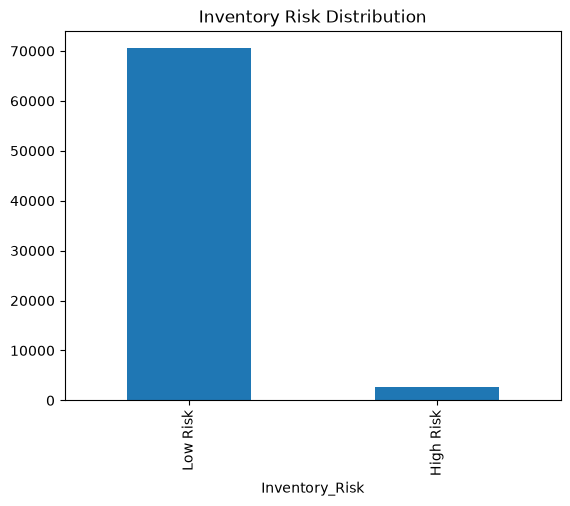

In [18]:
df['Inventory_Risk'].value_counts().plot(kind='bar')

plt.title('Inventory Risk Distribution')
plt.show()

In [19]:
df.groupby('Category')['Absolute_Forecast_Error'] \
  .mean() \
  .sort_values(ascending=False)

Category
Toys           8.386458
Furniture      8.353044
Clothing       8.347449
Groceries      8.328186
Electronics    8.274644
Name: Absolute_Forecast_Error, dtype: float64

In [20]:
df.groupby('Discount')['Units Sold'].mean()

Discount
0     135.694585
5     136.567405
10    136.769851
15    136.655293
20    136.640775
Name: Units Sold, dtype: float64

In [21]:
df.groupby('Weather Condition')['Units Sold'].mean()

Weather Condition
Cloudy    136.758324
Rainy     135.160028
Snowy     135.911559
Sunny     138.028650
Name: Units Sold, dtype: float64

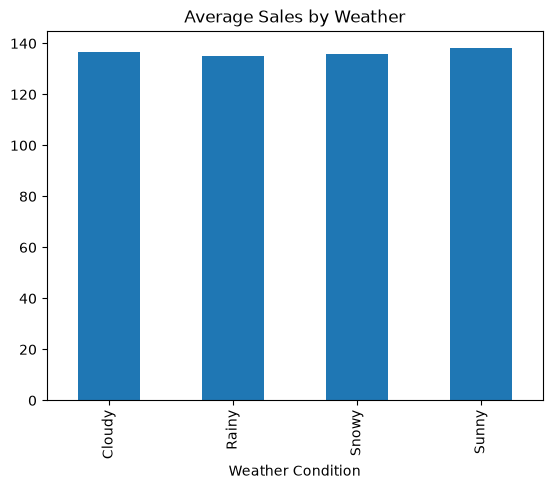

In [22]:
df.groupby('Weather Condition')['Units Sold'].mean().plot(kind='bar')

plt.title('Average Sales by Weather')
plt.show()

In [23]:
df.groupby('Holiday/Promotion')['Units Sold'].mean()

Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64

In [24]:
season_sales = (
    df.groupby('Seasonality')['Units Sold']
      .sum()
      .sort_values(ascending=False)
)

season_sales

Seasonality
Autumn    2506676
Winter    2501951
Spring    2487940
Summer    2479015
Name: Units Sold, dtype: int64

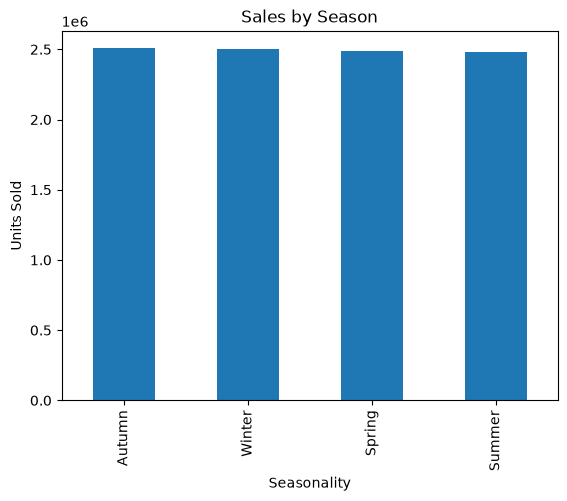

In [25]:
season_sales.plot(kind='bar')

plt.title('Sales by Season')
plt.ylabel('Units Sold')
plt.show()